In [7]:
import pandas as pd

df = pd.read_excel("/home/ntdung/Medical/data/participants.xlsx", nrows=1000)
df["image_path"] = df["subject_id"].apply(
    lambda x: f"data/{x}/anat/{x}_T1w.nii.gz"
)

bins = [0, 20, 40, 60, 100]
labels = ["0-20", "21-40", "41-60", "61+"]
df["age_group"] = pd.cut(df["subject_age"], bins=bins, labels=labels)

df

,No.,subject_age,subject_dx,subject_sex,subject_id,dataset_name,image_path,age_group
0,1,44.2,control,m,sub-BrainAge000019,ABIDE/Caltech,data/sub-BrainAge000019/anat/sub-BrainAge00001...,41-60
1,2,39.3,control,m,sub-BrainAge000020,ABIDE/Caltech,data/sub-BrainAge000020/anat/sub-BrainAge00002...,21-40
2,3,42.5,control,m,sub-BrainAge000021,ABIDE/Caltech,data/sub-BrainAge000021/anat/sub-BrainAge00002...,41-60
3,4,19.7,control,m,sub-BrainAge000022,ABIDE/Caltech,data/sub-BrainAge000022/anat/sub-BrainAge00002...,0-20
4,5,20.0,control,f,sub-BrainAge000023,ABIDE/Caltech,data/sub-BrainAge000023/anat/sub-BrainAge00002...,0-20
...,...,...,...,...,...,...,...,...
995,996,21.0,control,f,sub-BrainAge010923,ds003521,data/sub-BrainAge010923/anat/sub-BrainAge01092...,21-40
996,997,19.0,control,f,sub-BrainAge010924,ds003521,data/sub-BrainAge010924/anat/sub-BrainAge01092...,0-20
997,998,18.0,control,f,sub-BrainAge010925,ds003521,data/sub-BrainAge010925/anat/sub-BrainAge01092...,0-20
998,999,18.0,control,f,sub-BrainAge010926,ds003521,data/sub-BrainAge010926/anat/sub-BrainAge01092...,0-20


In [8]:
from datasets import Dataset

dataset = Dataset.from_pandas(df)
dataset

Dataset({
    features: ['No.', 'subject_age', 'subject_dx', 'subject_sex', 'subject_id', 'dataset_name', 'image_path', 'age_group'],
    num_rows: 1000
})

In [9]:
print("Distribution before splitting:")
print(pd.Series(dataset["age_group"]).value_counts())

Distribution before splitting:
21-40    483
0-20     301
41-60    116
61+      100
Name: count, dtype: int64


/home/ntdung/.local/lib/python3.10/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(


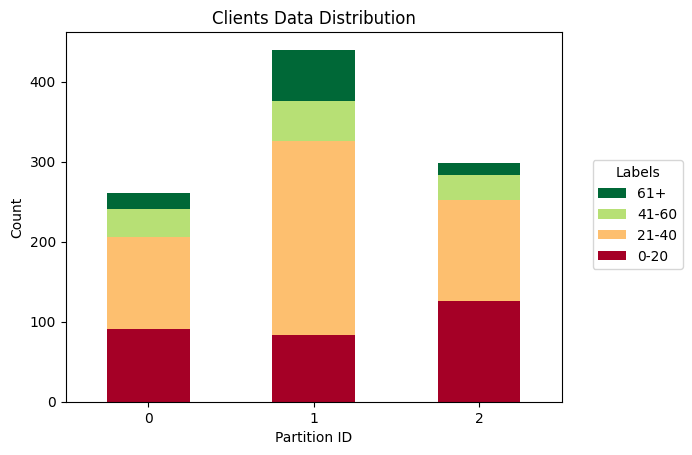

In [10]:
from flwr_datasets.partitioner import DirichletPartitioner
from flwr_datasets.visualization import plot_label_distributions
import matplotlib.pyplot as plt

num_clients = 3
partitioner = DirichletPartitioner(
    num_partitions=num_clients,
    partition_by="age_group",
    alpha=1.5,
    seed=42,
    min_partition_size=0,
)
partitioner.dataset = dataset

fig, ax, _ = plot_label_distributions(
    partitioner,
    label_name="age_group",
    plot_type="bar",
    size_unit="absolute",
    legend=True,
    verbose_labels=True,
    title=f"Clients Data Distribution"
)
plt.show()

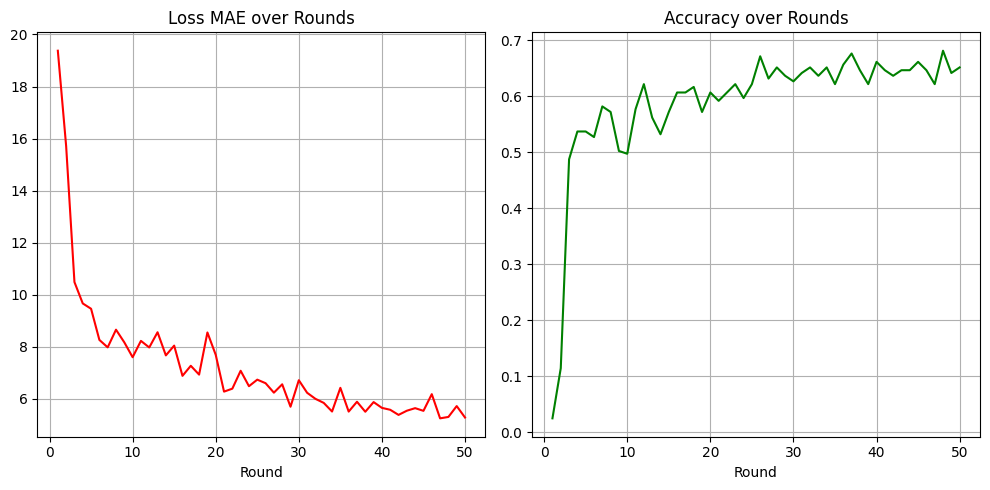

In [2]:
import json
import matplotlib.pyplot as plt

with open("results_fedprox_dirichlet.json", "r") as f:
    data = json.load(f)

epochs = sorted([int(k) for k in data.keys()])
loss = [data[str(epoch)]["mae"] for epoch in epochs]
accuracy = [data[str(epoch)]["accuracy"] for epoch in epochs]

plt.figure(figsize=(10, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, color='red')
plt.title("Loss MAE over Rounds")
plt.xlabel("Round")
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, color='green')
plt.title("Accuracy over Rounds")
plt.xlabel("Round")
plt.grid(True)

plt.tight_layout()
plt.show()